In [2]:
from IPython.lib.display import Audio

%load_ext autoreload
%autoreload 2

from src.main.controller.AASVCController import AASVCController

controller = AASVCController()
path_dataset = r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\dataset\cv-corpus-mozilla-pt\data/"
path_model_checkpoint = r"C:\Users\USER\Documents\Mestrado\codigo\Mestrado_VC\src\config\modelCheckpoint\AASVC\checkpoint-250000steps.pkl"


audio,mel_m,mel_noise, mel_org, audio_org = controller.inference(path_model_checkpoint, path_dataset)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


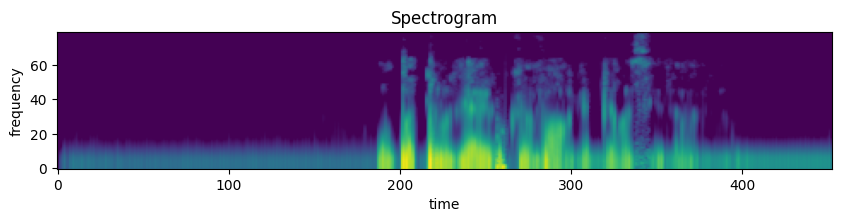

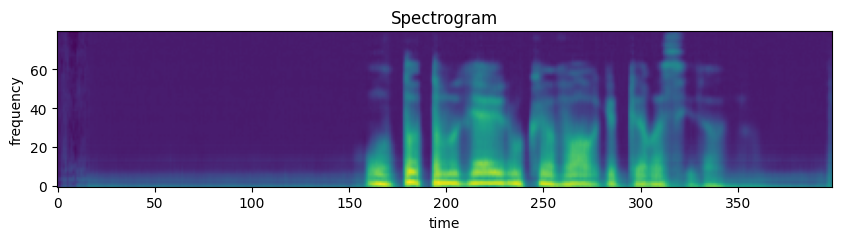

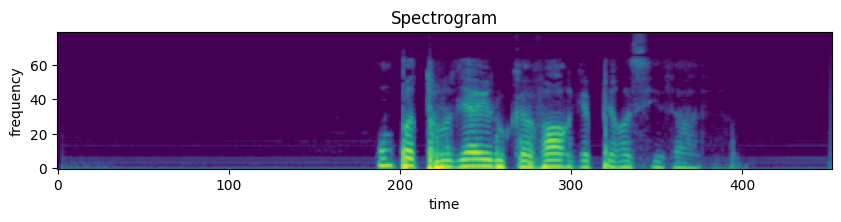

In [3]:
import torch
%matplotlib inline
from src.common.utils.visualizar import vizualizar_spectrogram

B = 1
T = 380
F = 80

vizualizar_spectrogram(torch.Tensor(mel_noise).transpose(0,1))
vizualizar_spectrogram(mel_m.transpose(0,1))
vizualizar_spectrogram(torch.Tensor(mel_org).transpose(0,1))


HiFi-GAN: Removing weight norm.


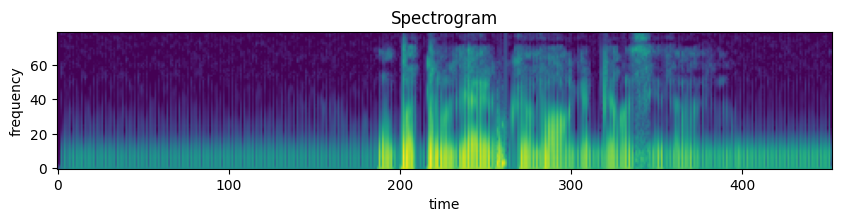

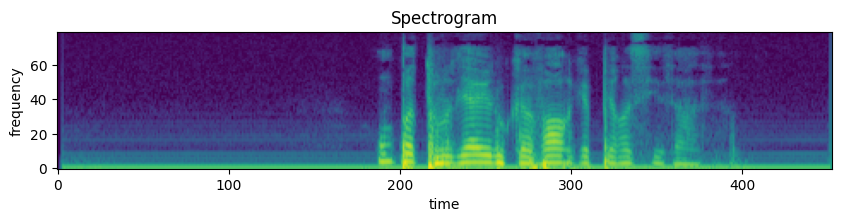

In [6]:
from src.common.pre_processamento.noise import f0_constante
from src.common.pre_processamento.spectograma import gerar_mel_spectogram
import numpy as np
import librosa
from src.common.vocoder.HiFiGAN import inference

def create_mel(audio):
    return gerar_mel_spectogram(audio)
    # mel = librosa.feature.melspectrogram(
    #         y=audio_org,
    #         sr=22050,
    #         n_fft=1024,
    #         hop_length=256,
    #         win_length=None,
    #         n_mels=80,
    #         fmin=80,
    #         fmax=22050 // 2, # 7600
    #         power=2.0,
    #     )
    # # converte para log-mel
    # mel = librosa.power_to_db(mel, ref=np.max)
    # 
    # # mel vem (80, T) → queremos (T, 80)
    # mel = mel.T

audio_ruido = f0_constante(audio_org.astype(np.float64), 22050, f0_floor=25.0, f0_ceil=90.0, frame_period=1.0, speed=1, f0_contante=60.0)
mel = create_mel(torch.Tensor(audio_ruido))
mel_n = create_mel(torch.Tensor(audio_org))
vizualizar_spectrogram(torch.Tensor(mel))
vizualizar_spectrogram(torch.Tensor(mel_n))

mel_for_vocoder = torch.Tensor(mel)
audio_pred = inference(torch.Tensor(mel_for_vocoder).to('cuda')).cpu().detach()
audio_pred = audio_pred[0].cpu().detach().numpy()
Audio(audio_ruido, rate=22050)

In [ ]:
Audio(audio_pred, rate=22050)

In [221]:
Audio(audio, rate=22050)

In [121]:
mel_res = mel_m.unsqueeze(0)
print(mel_res.shape)
mel_res = mel_res.permute(1, 2, 0).shape

torch.Size([1, 400, 80])


In [190]:
mel_m.transpose(0,1).unsqueeze(0).shape

torch.Size([1, 80, 400])

In [199]:
from src.common.vocoder.HiFiGAN import inference
print(torch.Tensor(mel_res).shape)

mel_for_vocoder = torch.Tensor(mel_org)
audio_pred = inference(torch.Tensor(mel_for_vocoder.transpose(1,0).unsqueeze(0)).to('cuda')).cpu().detach()
print(audio_pred.shape)
audio_pred = audio_pred[0].cpu().detach().numpy()
Audio(audio_pred, rate=22050)

torch.Size([400, 80, 1])
HiFi-GAN: Removing weight norm.
torch.Size([1, 1, 115968])


In [180]:
from scipy.io.wavfile import write
write("audio.wav", 22050, torch.Tensor(audio_numpy).cpu().detach().numpy())
